In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import date2num
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

In [59]:
# Load data
df = pd.read_csv('historical_stablecoin.csv')
df['date'] = pd.to_datetime(df['date'])

df.head()

,date,peggedUSD,peggedEUR,peggedVAR,peggedJPY,peggedCNY,peggedUAH,peggedARS,peggedGBP,peggedCAD,peggedCHF,peggedAUD,peggedREAL
0,2021-01-01,28286859559,3871222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,28825490421,4272046,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,28995680791,5510939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-04,29328599685,5971796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-05,29771217419,7836686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
# Detect first non null date for each column
first_dates = {}
for col in df.columns[1:]:  # Skip Date column
    non_null = df[col].notna()
    if non_null.any():
        idx = non_null.idxmax()
        first_dates[col] = df.loc[idx, 'date']
    else:
        first_dates[col] = pd.NaT

launch_df = pd.DataFrame([{'currency': k, 'launch_date': v} for k, v in first_dates.items()])
launch_df = launch_df.sort_values('launch_date').reset_index(drop=True)

print("Launch Dates of Stablecoins:")
print(launch_df)

Launch Dates of Stablecoins:
      currency launch_date
0    peggedUSD  2021-01-01
1    peggedEUR  2021-01-01
2    peggedVAR  2021-02-14
3    peggedJPY  2023-08-10
4    peggedCNY  2023-09-01
5    peggedUAH  2023-10-04
6    peggedARS  2023-10-06
7    peggedGBP  2023-11-23
8    peggedCAD  2023-12-08
9    peggedCHF  2024-01-25
10   peggedAUD  2024-03-06
11  peggedREAL  2024-07-03


# EDA

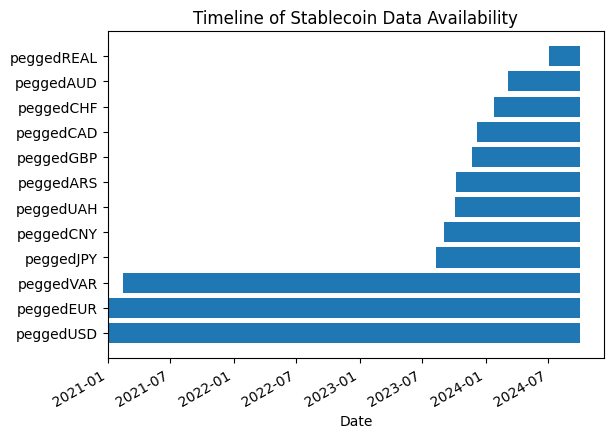

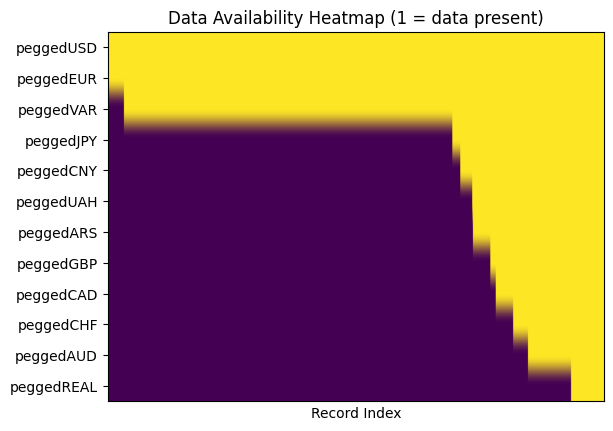

In [61]:
# Plot horizontal timeline of launches
last_date = df['date'].max()
starts = date2num(launch_df['launch_date'])
widths = date2num(last_date) - starts

plt.figure()
plt.barh(launch_df['currency'], widths, left=starts)
plt.xlabel('Date')
plt.title('Timeline of Stablecoin Data Availability')
plt.gca().xaxis_date()
plt.gcf().autofmt_xdate()
plt.show()

# Plot heatmap of data availability
availability = df.set_index('date')[launch_df['currency']].notna().T.astype(int)

plt.figure()
plt.imshow(availability, aspect='auto')
plt.yticks(range(len(availability.index)), availability.index)
plt.xticks([], [])
plt.xlabel('Record Index')
plt.title('Data Availability Heatmap (1 = data present)')
plt.show()

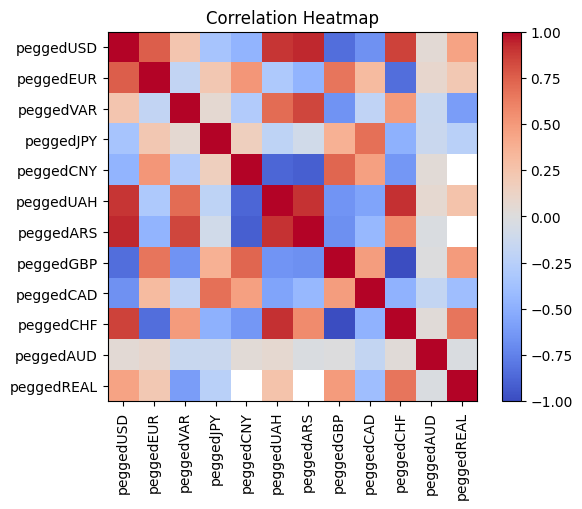

In [62]:
# Correlation Heatmap 
plt.figure()
corr = df.drop(columns='date').corr()
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.index)
plt.title('Correlation Heatmap')
plt.show()

# Deteksi Anomali

In [63]:
monthly = df.set_index('date')['peggedUSD']\
             .resample('M').last()\
             .dropna()


monthly_all = (
    df.set_index('date')[coins]
      .resample('M')
      .last()
      .dropna(how='all')
)

/var/folders/gs/b23h8b0d4h73h3gp616lr10c0000gn/T/ipykernel_67816/1246339057.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M').last()\
/var/folders/gs/b23h8b0d4h73h3gp616lr10c0000gn/T/ipykernel_67816/1246339057.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


In [64]:
# Anomali supply (Z-score > 3)
z_supply     = (monthly - monthly.mean()) / monthly.std()
supply_anoms = monthly[abs(z_supply) > 3]

# Anomali growth rate (Z-score > 3)
growth       = monthly.pct_change().dropna() * 100
z_growth     = (growth - growth.mean()) / growth.std()
growth_anoms = growth[abs(z_growth) > 3]

# Print
print("=== Supply Anomalies (Z>3) ===")
print(supply_anoms.to_string())

print("\n=== Growth Anomalies (Z>3) ===")
print(growth_anoms.to_string())

=== Supply Anomalies (Z>3) ===
date
2021-01-31    37189036128
Freq: ME

=== Growth Anomalies (Z>3) ===
date
2021-02-28    38.646913
2021-04-30    35.157105


# VISUALISASI

<Figure size 640x480 with 0 Axes>

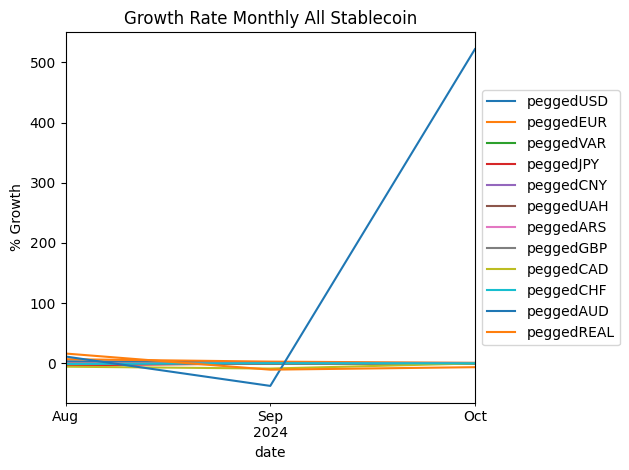

In [65]:
# Growth Rate All Stablecoin
coins = df.columns.drop('date')
growth_all = monthly_all.pct_change() * 100

plt.figure()
growth_all.dropna().plot()
plt.ylabel('% Growth')
plt.title('Growth Rate Monthly All Stablecoin')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

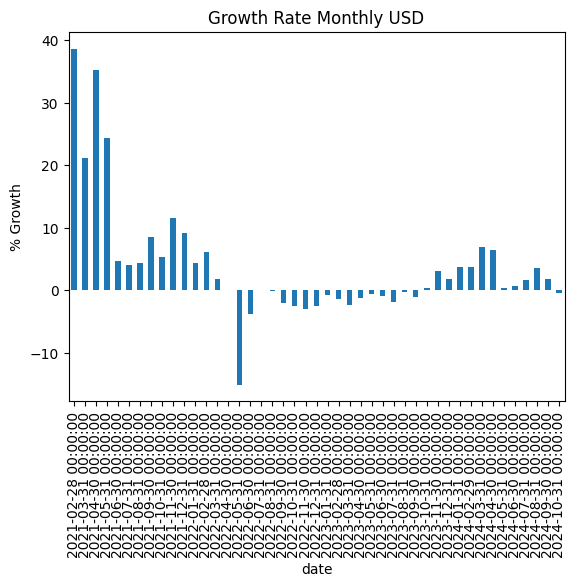

In [66]:
# Growth rate monthly
growth = monthly.pct_change().dropna() * 100
growth.plot.bar()
plt.ylabel('% Growth')
plt.title('Growth Rate Monthly USD')
plt.show()


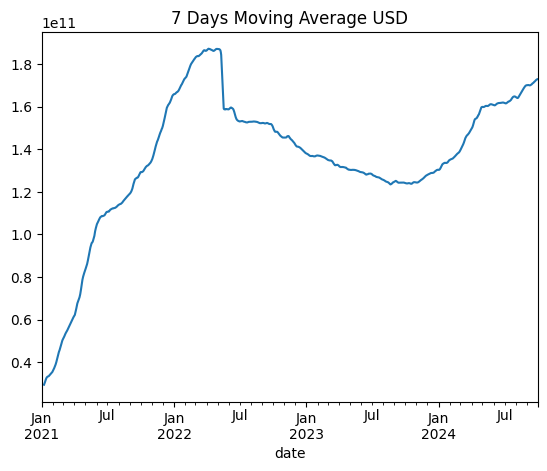

In [67]:
# 7 Days MA
df.set_index('date')['peggedUSD'].rolling(7).mean().plot()
plt.title('7 Days Moving Average USD')
plt.show()


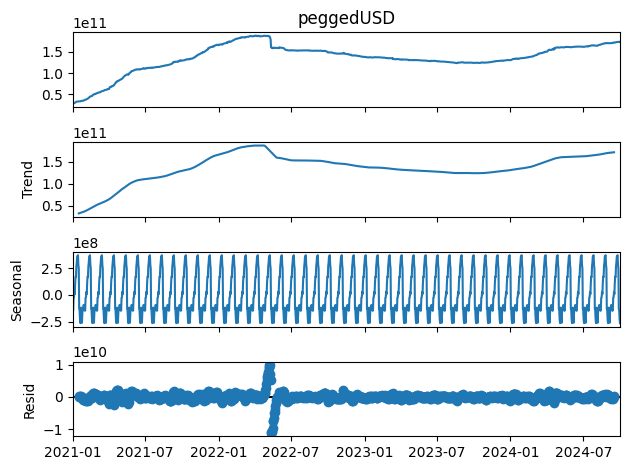

In [68]:
# Seasonal Decomposition USD
series = df.set_index('date')['peggedUSD'].dropna()
res = seasonal_decompose(series, model='additive', period=30)
res.plot()
plt.show()

# Forecasting

21:31:57 - cmdstanpy - INFO - Chain [1] start processing
21:31:57 - cmdstanpy - INFO - Chain [1] done processing


Text(0.5, 0.98, '30-Day Forecast of USD-Pegged Stablecoin Supply')

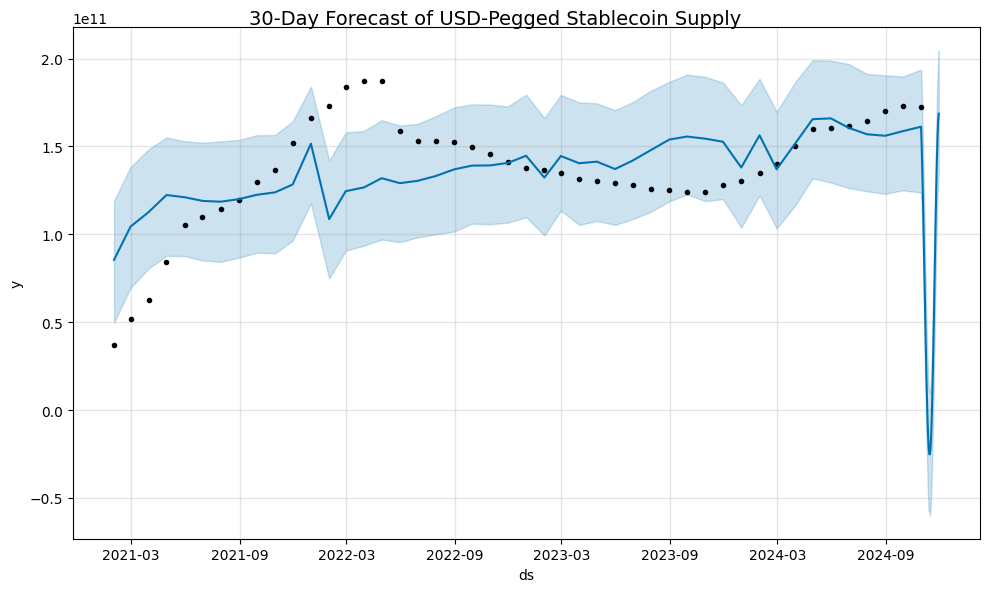

In [69]:
# 30 Days forecast
df_prophet = monthly.reset_index().rename(columns={'date':'ds','peggedUSD':'y'})
m = Prophet(); m.fit(df_prophet)
future = m.make_future_dataframe(periods=30, freq='D')
fc = m.predict(future)
fig = m.plot(fc)
fig.suptitle('30-Day Forecast of USD-Pegged Stablecoin Supply', fontsize=14)


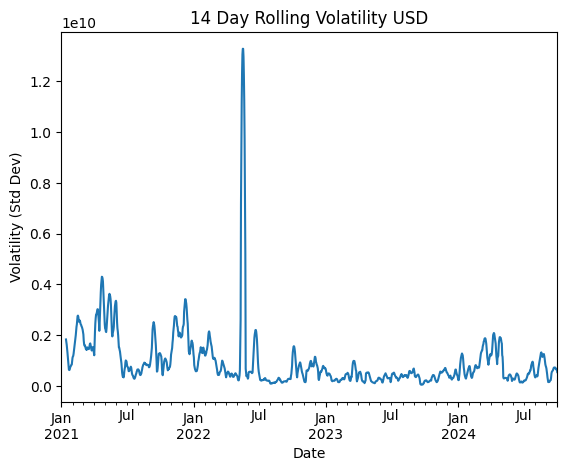

In [70]:
# 14 Day Rolling Volatility
vol = df.set_index('date')['peggedUSD'].rolling(14).std()

plt.figure()
vol.plot()
plt.xlabel('Date')
plt.ylabel('Volatility (Std Dev)')
plt.title('14 Day Rolling Volatility USD')
plt.show()

Evaluation on Test Set (last 12 months):
MAPE: 18.95%
RMSE: 34,558,035,172


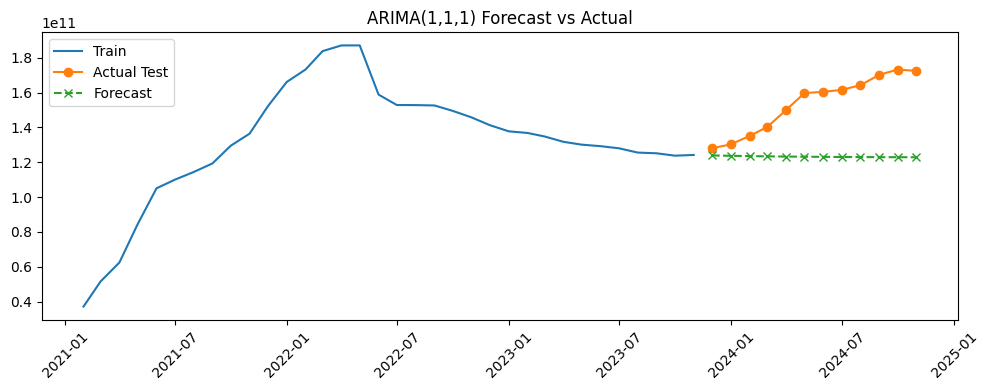

In [71]:
# Split for ARIMA
train = monthly[:-12]
test = monthly[-12:]

# Fit ARIMA(1,1,1)
model = ARIMA(train, order=(1,1,1)).fit()

# Forecast for test period
pred = model.forecast(steps=12)

# Calculate error metrics
mape = mean_absolute_percentage_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))

print(f"Evaluation on Test Set (last 12 months):")
print(f"MAPE: {mape*100:.2f}%")
print(f"RMSE: {rmse:,.0f}")

# Plot Test vs Forecast
plt.figure(figsize=(10, 4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, 'o-', label='Actual Test')
plt.plot(pred.index, pred, 'x--', label='Forecast')
plt.title('ARIMA(1,1,1) Forecast vs Actual')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


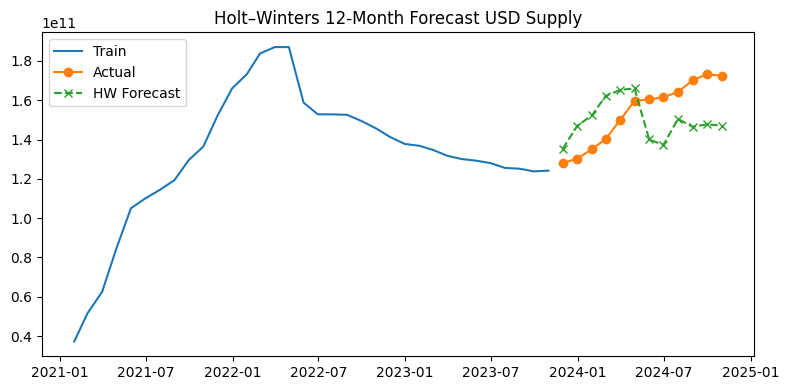

In [72]:
# Fit Holt-Winters (additive trend & seasonal)
hw_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

# Forecast 12 bulan ke depan
hw_forecast = hw_model.forecast(12)

# Plot hasil
plt.figure(figsize=(8,4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, 'o-', label='Actual')
plt.plot(hw_forecast.index, hw_forecast, 'x--', label='HW Forecast')
plt.title('Holt–Winters 12-Month Forecast USD Supply')
plt.legend()
plt.tight_layout()
plt.show()

/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few obs

Best SARIMAX params: order=(0, 0, 0), seasonal_order=(2, 2, 2, 12), AIC=10.0
MAPE: 35.53%
RMSE: 61,070,460,905


/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


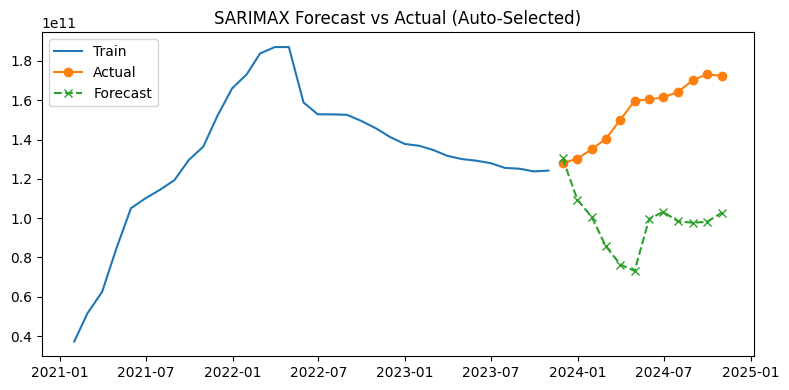

In [73]:
# Grid search for best SARIMAX(p,d,q)(P,D,Q,12) by AIC
p = d = q = range(0, 3)
pdq = [(x[0], x[1], x[2]) for x in zip(p, d, q)]
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in zip(p, d, q)]

best_aic = float('inf')
best_params = None
best_model = None

for order in pdq:
    for seasonal_order in seasonal_pdq:
        try:
            mod = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                          enforce_stationarity=False, enforce_invertibility=False)
            res = mod.fit(disp=False)
            if res.aic < best_aic:
                best_aic = res.aic
                best_params = (order, seasonal_order)
                best_model = res
        except Exception:
            continue

print(f"Best SARIMAX params: order={best_params[0]}, seasonal_order={best_params[1]}, AIC={best_aic:.1f}")

# Forecast with best model
forecast = best_model.get_forecast(steps=12)
pred = forecast.predicted_mean

# Compute error metrics
mape = mean_absolute_percentage_error(test, pred)
mse  = mean_squared_error(test, pred)
rmse = np.sqrt(mse)
print(f"MAPE: {mape*100:.2f}%")
print(f"RMSE: {rmse:,.0f}")

# Plot actual vs forecast
plt.figure(figsize=(8, 4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, 'o-', label='Actual')
plt.plot(pred.index, pred, 'x--', label='Forecast')
plt.title('SARIMAX Forecast vs Actual (Auto-Selected)')
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/gs/b23h8b0d4h73h3gp616lr10c0000gn/T/ipykernel_67816/585744244.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M').last().dropna()
21:31:58 - cmdstanpy - INFO - Chain [1] start processing
21:31:58 - cmdstanpy - INFO - Chain [1] done processing
/opt/miniconda3/lib/python3.12/site-packages/prophet/forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


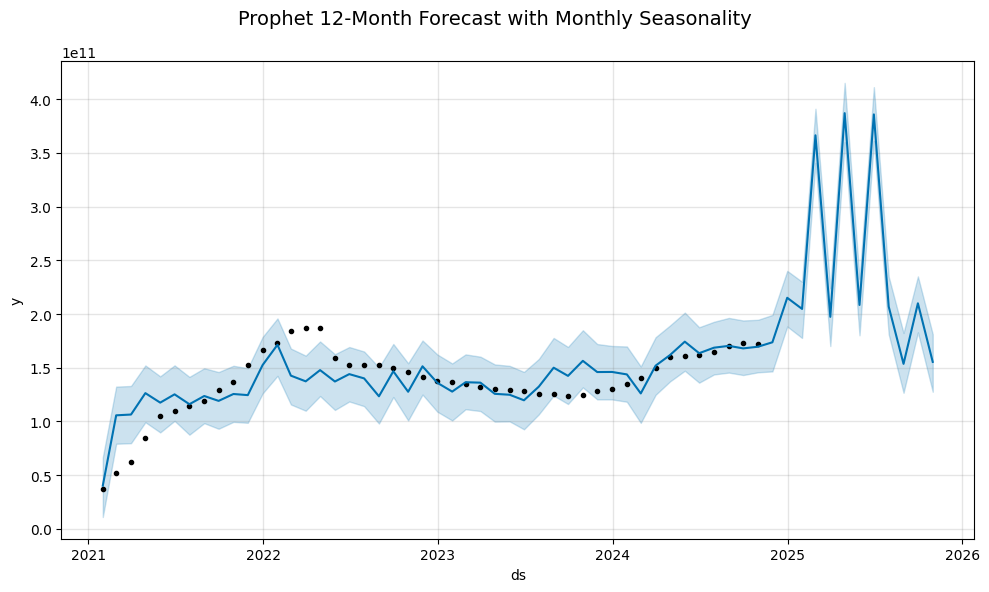

In [74]:
df_prophet = (
    df.set_index('date')['peggedUSD']
      .resample('M').last().dropna()
      .reset_index()
      .rename(columns={'date':'ds','peggedUSD':'y'})
)

m = Prophet(
    yearly_seasonality=True,      # tangkap pola tahunan
    weekly_seasonality=False,
    daily_seasonality=False
)
m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
m.fit(df_prophet)

future = m.make_future_dataframe(periods=12, freq='M')
fc     = m.predict(future)

fig = m.plot(fc)
fig.suptitle('Prophet 12-Month Forecast with Monthly Seasonality', fontsize=14)
plt.tight_layout()
plt.show()
